In [8]:
from src.utils import get_path, find_closest_power_of_2, set_device
from src.MSQDDPM_angel import WassDistance
from src.trainers.basic_trainers import QDDPMGeneratorInitialqstates
from opt_einsum import contract
from qutip import Bloch
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import torch

def bloch_xyz(rho):
    # obtain bloch sphere representation vector
    # rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

config = {
    'device': 'cuda:0',
    'dataset': {
        'dir': './results_MSQDDPM',
        'name': 'CIRCLEY_1',
        # 'transforms': {
        #     'resize': 16
        # },
        'maxsize': 300,
    },
    'model': {
        'n_timesteps': 6,
        'n_ancilla_qubits': 2,
        'n_backward_layers': 8,
        'diffusion_schedule': {
            'name': 'linear',
            # 'slope': 2,
            # 'vrescale': 50,
            # 'hrescale': 26
        }
    }
}
n_qubits = 1
n_features = 2**n_qubits
diffusion_schedule_nickname = config['model']['diffusion_schedule']['name']

n_data = config['dataset']['maxsize']
n_timesteps = config['model']['n_timesteps']
device = set_device(config.get('device', 'cpu'))
torch.set_default_device(device)

Using device: cuda:0


# Diffuse

In [ ]:
from src.MSQDDPM_angel import DiffusionModel

dir, filename = get_path(config, type='diffusedqstates.npy', diffusion_schedule=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
path = dir/filename

# Check if initial states exist
dir, filename = get_path(config, type='initialqstates.npy', n_data=n_data, n_features=n_features, n_qubits=n_qubits)
path = dir/filename
if not path.exists():
    # Generate initial states
    print("Initial quantum states not found. Generating them...")
    generator_initialqstates = QDDPMGeneratorInitialqstates(config)
    generator_initialqstates.generate_initialqstates()

# Load generated initial states
dir, filename = get_path(config, type='initialqstates.npy', n_data=n_data, n_features=n_features, n_qubits=n_qubits)
initial_qstates = torch.from_numpy(np.load(dir/filename)).to(device) # [n_data, n_features]
print(initial_qstates.shape)

# Diffuse
diffuser = DiffusionModel(n_qubits, n_timesteps, n_data, device=device)
rhos = diffuser.density_matrices_ensemble_from_pure_states_ensemble(initial_qstates)
print(rhos.shape)
rhos_diffused = torch.zeros((n_timesteps+1, n_data, n_features, n_features), dtype=torch.complex64, device=device)
rhos_diffused[0] = rhos
for t in tqdm(range(1,n_timesteps+1)):
    rhos_diffused[t] = diffuser.depolarizing_channel_t(rhos_diffused[0], t)
dir, filename = get_path(config, type='diffusedqstates.npy', diffusion_schedule=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
np.save(dir/filename, rhos_diffused.cpu().numpy())

torch.Size([300, 2])
torch.Size([300, 2, 2])


100%|██████████| 6/6 [00:00<00:00, 53.90it/s]


# Visualizations

100%|██████████| 7/7 [00:00<00:00, 149.10it/s]

0 torch.Size([300, 2, 2]) torch.Size([300, 2, 2])
1 torch.Size([300, 2, 2]) torch.Size([300, 2, 2])
2 torch.Size([300, 2, 2]) torch.Size([300, 2, 2])
3 torch.Size([300, 2, 2]) torch.Size([300, 2, 2])
4 torch.Size([300, 2, 2]) torch.Size([300, 2, 2])
5 torch.Size([300, 2, 2]) torch.Size([300, 2, 2])
6 torch.Size([300, 2, 2]) torch.Size([300, 2, 2])


Text(0.5, 1.0, 'Quantum state distribution during the forward process.\nlinear')

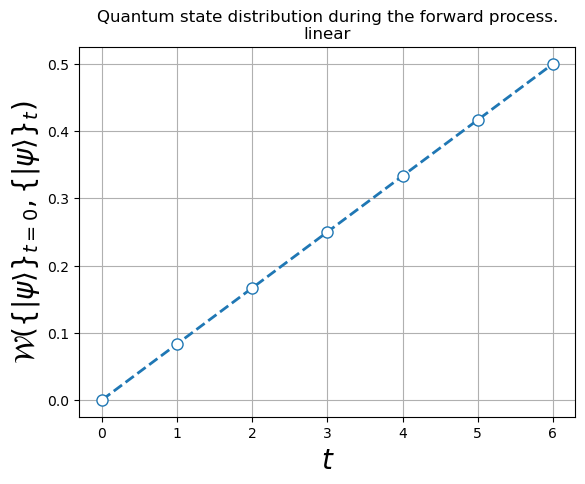

In [ ]:
# Wasserstein distance evolution
dir, filename = get_path(config, type='wassdistforward.npy', diffusion_schedule=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
if not (dir / filename).exists():
    dir, filename = get_path(config, type='diffusedqstates.npy', diffusion_schedule=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
    rhos_diffused = torch.from_numpy(np.load(dir / filename))

    wass = np.zeros(n_timesteps+1)
    for t in tqdm(range(n_timesteps+1)):
        np.random.seed()
        wass[t] = WassDistance(rhos_diffused[0], rhos_diffused[t]).detach().numpy()
        dir, filename = get_path(config, type='wassdistforward.npy', diffusion_schedule=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
        np.save(dir / filename, wass)

dir, filename = get_path(config, type='wassdistforward.npy', diffusion_schedule=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
wass = np.load(dir / filename)

fig, ax1 = plt.subplots()
ax1.plot(wass, 'o--', mfc='white', markersize=8, lw=2)

ax1.set_ylabel(r'$\mathcal{W}\left(\{|\psi\rangle\}_{t=0}, \{|\psi\rangle\}_{t} \right)$', fontsize=20)
ax1.set_xlabel(r'$t$', fontsize=20)
# plt.xticks(range(n_timesteps+1))
ax1.grid(True)
ax1.set_title(f'Quantum state distribution during the forward process.\n{diffusion_schedule_nickname}')


## Bloch visualization 

100%|██████████| 7/7 [00:01<00:00,  4.03it/s]


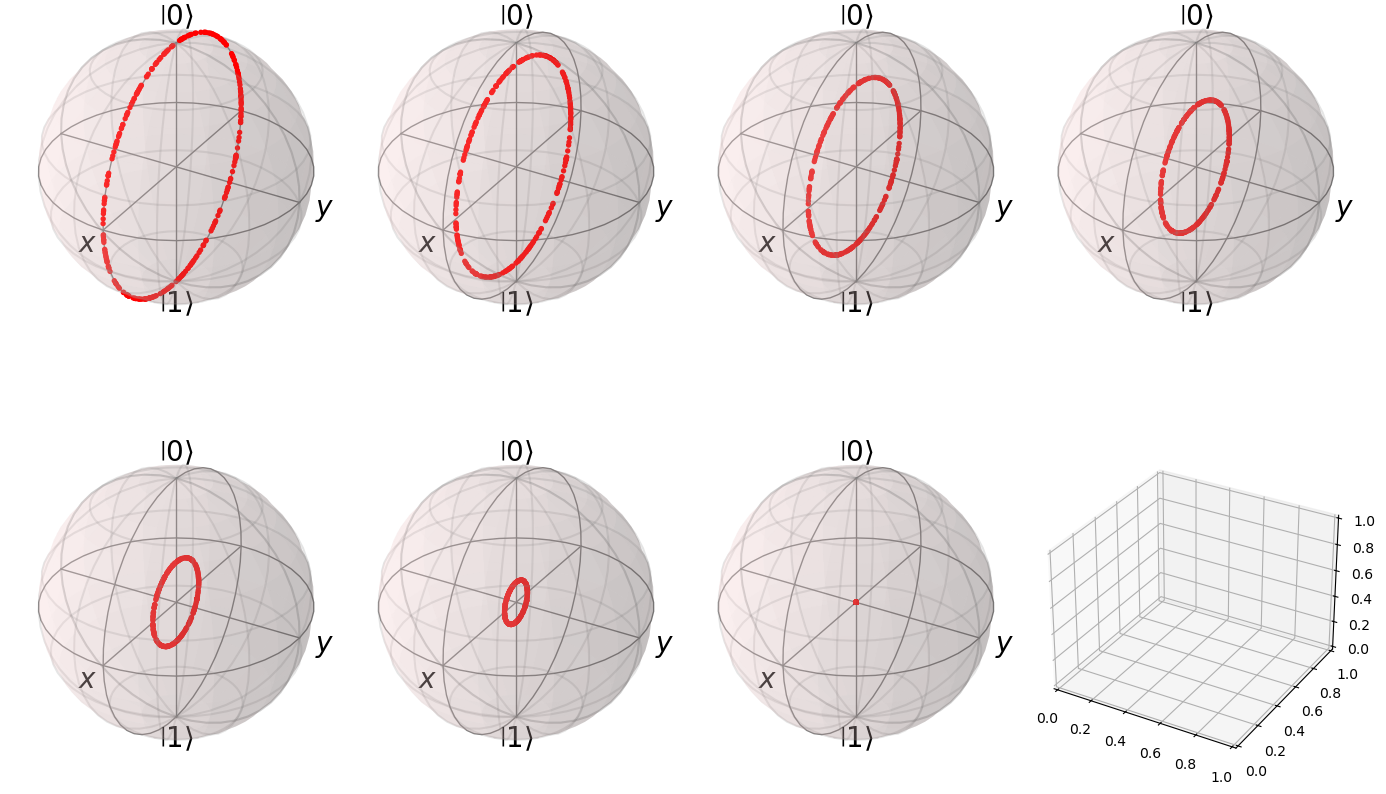

In [13]:
# Bloch visualize on the forward noise process
dir, filename = get_path(config, type='diffusedqstates.npy', diffusion_schedule=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits,n_timesteps=n_timesteps)
rhos_diffused = np.load(dir / filename)

rows = 2
cols = 4
fig, axs = plt.subplots(rows, cols, figsize=(14,10), subplot_kw={'projection': '3d'})
for i in tqdm(range(n_timesteps+1)):
    xs0, ys0, zs0 = bloch_xyz(rhos_diffused[i])
    b0 = Bloch(fig=fig, axes=axs[i//cols, i%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['r']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()
plt.tight_layout()